<a href="https://colab.research.google.com/github/NinaAbeyratne/graphfact-fake-news-gnn/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Drive Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cloning repo

In [2]:
!git clone https://github.com/NinaAbeyratne/graphfact-fake-news-gnn.git
%cd graphfact-fake-news-gnn

Cloning into 'graphfact-fake-news-gnn'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 33 (delta 6), reused 21 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 10.55 KiB | 360.00 KiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/graphfact-fake-news-gnn


## Library Installation

In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn sentence-transformers torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 835.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.1 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

print("Setup completed successfully")

Setup completed successfully


## Load Dataset

In [5]:
# Download latest version
path = kagglehub.dataset_download("doanquanvietnamca/liar-dataset")

print("Path to dataset files:", path)

100%|██████████| 0.98M/0.98M [00:00<00:00, 1.11MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/doanquanvietnamca/liar-dataset/versions/1


In [6]:
dt = "/root/.cache/kagglehub/datasets/doanquanvietnamca/liar-dataset/versions/1/train.tsv"
train = pd.read_csv(dt, sep="\t")
train.sample(3)

,2635.json,false,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,State representative,Texas,republican,0,1,0.1,0.2,0.3,a mailer
2428,12471.json,pants-fire,Says Obama wants to give (Iran) nuclear weapon...,nuclear,jon-keyser,NaN,Colorado,republican,0.0,1.0,0.0,0.0,1.0,a TV ad
6619,9484.json,pants-fire,Says Barack Obama said that ordinary men and w...,foreign-policy,chain-email,NaN,NaN,none,11.0,43.0,8.0,5.0,105.0,emails and social media posts circulating on t...
9690,7637.json,true,"In Rhode Island, 28 percent of adults released...","crime,criminal-justice,economy,government-regu...",ban-the-box-ri,NaN,Rhode Island,organization,0.0,0.0,0.0,0.0,0.0,a video posted on YouTube


## Inspect Columns

#### Description

Column 1: the ID of the statement ([ID].json).\
Column 2: the label.\
Column 3: the statement.\
Column 4: the subject(s).\
Column 5: the speaker.\
Column 6: the speaker's job title.\
Column 7: the state info.\
Column 8: the party affiliation.\
Column 9-13: the total credit history count, including the current statement.\
9: barely true counts.\
10: false counts.\
11: half true counts.\
12: mostly true counts.\
13: pants on fire counts.\
Column 14: the context (venue / location of the speech or statement).

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10239 entries, 0 to 10238
Data columns (total 14 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   2635.json                                                                           10239 non-null  object 
 1   false                                                                               10239 non-null  object 
 2   Says the Annies List political group supports third-trimester abortions on demand.  10239 non-null  object 
 3   abortion                                                                            10237 non-null  object 
 4   dwayne-bohac                                                                        10237 non-null  object 
 5   State representative                                                                7341 non-nu

In [8]:
train = train.drop(train.columns[0], axis=1)

In [9]:
train.columns = ["label", "statement", "subject", "speaker", "speaker-title", "state", "party-affiliation", "barely-true", "false", "half-true", "mostly-true", "pof", "context"]


In [10]:
train.head(5)

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context
0,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


In [11]:
# samples for each label

train["label"].value_counts()

,count
label,
half-true,2114
false,1994
mostly-true,1962
true,1676
barely-true,1654
pants-fire,839


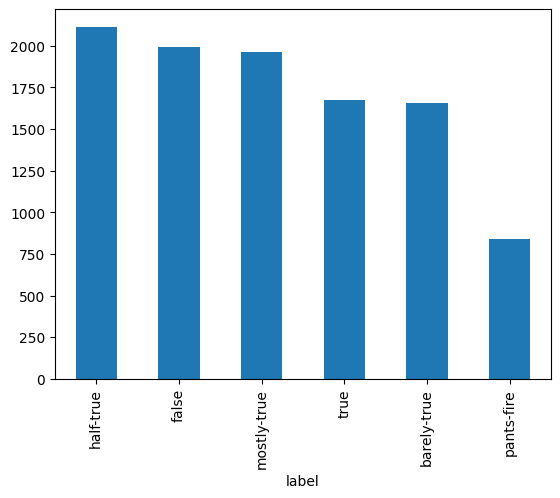

In [12]:
train["label"].value_counts().plot(kind="bar")
plt.show()

In [13]:
# nulls values of each feature

train.isnull().sum()

,0
label,0
statement,0
subject,2
speaker,2
speaker-title,2898
state,2210
party-affiliation,2
barely-true,2
false,2
half-true,2


In [14]:
train["speaker"].sample(3)

,speaker
8495,bernie-s
5593,mary-burke
1333,rob-portman


In [15]:
# unique speakers

len(train["speaker"].unique())

2910

In [16]:
# unqiue speaker titles

len(train["speaker-title"].unique())

1184

In [17]:
# unique state count

len(train["state"].unique())

84

In [18]:
# unique subject count

len(train["subject"].unique())

3828

In [19]:
# unique party affiliation count

len(train["party-affiliation"].unique())

24

In [20]:
# unique context count

len(train["context"].unique())

4346

In [21]:
filt_barely_true = train["label"] == "barely-true"
train[filt_barely_true]

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context
5,barely-true,Jim Dunnam has not lived in the district he re...,candidates-biography,republican-party-texas,NaN,Texas,republican,3.0,1.0,1.0,3.0,1.0,a press release.
13,barely-true,Most of the (Affordable Care Act) has already ...,health-care,george-will,Columnist,Maryland,columnist,7.0,6.0,3.0,5.0,1.0,"comments on ""Fox News Sunday"""
16,barely-true,"U.S. Rep. Ron Kind, D-Wis., and his fellow Dem...",federal-budget,national-republican-congressional-committee,NaN,NaN,republican,18.0,9.0,8.0,5.0,8.0,a news release
23,barely-true,Says Mitt Romney wants to get rid of Planned P...,"abortion,federal-budget,health-care",planned-parenthood-action-fund,Advocacy group,"Washington, D.C.",none,1.0,0.0,0.0,0.0,0.0,a radio ad
30,barely-true,"If you look at states that are right to work, ...","economy,labor,states,unions,workers",nicholas-kettle,State senator,Rhode Island,republican,1.0,0.0,0.0,0.0,0.0,a radio talk show
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10212,barely-true,Theres a tremendous other number of public off...,"technology,transparency",howard-dean,Democratic National Committee chairman,Vermont,democrat,1.0,4.0,1.0,2.0,0.0,"an interview on ""Morning Joe"""
10214,barely-true,"The Obama administration spent $205,075 in sti...","economy,stimulus",ted-cruz,Senator,Texas,republican,36.0,33.0,15.0,19.0,8.0,a report
10223,barely-true,"In 2012, the state put together a list of over...",elections,charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,a speech to Louisiana Democrats
10227,barely-true,Stopped by Smiley Cookie to pick up some great...,food,donald-trump,President-Elect,New York,republican,63.0,114.0,51.0,37.0,61.0,a Facebook post.


In [22]:
# check duplicated rows

len(train) - len(train.drop_duplicates())

1

In [23]:
train[train.duplicated]

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context
4838,half-true,During Sherrod Browns past decade as a D.C. po...,"economy,job-accomplishments,jobs",josh-mandel,Ohio treasurer,Ohio,republican,4.0,5.0,4.0,5.0,6.0,a news release


In [24]:
# remove duplicated rows

train = train.drop_duplicates()
train.shape[0]

10238

In [25]:
train['cumalative'] = train.apply(lambda row: row['barely-true'] + row['false'] + row['half-true'] + row['mostly-true'] + row['pof'], axis=1)
train['cumalative'].head(5)

,cumalative
0,2.0
1,473.0
2,78.0
3,65.0
4,11.0


In [26]:
train_extended = train.copy()
train_extended.drop(columns=["subject", "speaker-title", "state", "party-affiliation", "context", "cumalative", "label","barely-true", "false", "half-true", "mostly-true", "pof"], inplace=True)
train_extended.head(3)

,statement,speaker
0,When did the decline of coal start? It started...,scott-surovell
1,"Hillary Clinton agrees with John McCain ""by vo...",barack-obama
2,Health care reform legislation is likely to ma...,blog-posting


In [27]:
len(train_extended) - len(train_extended.drop_duplicates())

4

In [28]:
train_extended[train_extended.duplicated()]

,statement,speaker
1845,"Obama says Iran is a 'tiny' country, 'doesn't ...",john-mccain
2845,"Four balanced budgets in a row, with no new ta...",chris-christie
7247,On the status of illegal immigrants,scott-walker
9749,"Some 20,000 Delphi salaried retirees lost up t...",michael-turner


In [29]:
train_extended.index[train_extended.duplicated(keep=False)].tolist()

[847, 1525, 1845, 2845, 6965, 7247, 8857, 9749]

In [30]:
train_extended.loc[train_extended.index[train_extended.duplicated(keep=False)].tolist()]

,statement,speaker
847,"Obama says Iran is a 'tiny' country, 'doesn't ...",john-mccain
1525,"Four balanced budgets in a row, with no new ta...",chris-christie
1845,"Obama says Iran is a 'tiny' country, 'doesn't ...",john-mccain
2845,"Four balanced budgets in a row, with no new ta...",chris-christie
6965,On the status of illegal immigrants,scott-walker
7247,On the status of illegal immigrants,scott-walker
8857,"Some 20,000 Delphi salaried retirees lost up t...",michael-turner
9749,"Some 20,000 Delphi salaried retirees lost up t...",michael-turner


In [31]:
train.loc[train_extended.index[train_extended.duplicated(keep=False)].tolist()]

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context,cumalative
847,false,"Obama says Iran is a 'tiny' country, 'doesn't ...",foreign-policy,john-mccain,U.S. senator,Arizona,republican,31.0,39.0,31.0,37.0,8.0,a TV ad airing in Florida,146.0
1525,half-true,"Four balanced budgets in a row, with no new ta...","education,state-budget,state-finances",chris-christie,Governor of New Jersey,New Jersey,republican,10.0,17.0,27.0,19.0,8.0,a TV ad,81.0
1845,false,"Obama says Iran is a 'tiny' country, 'doesn't ...",foreign-policy,john-mccain,U.S. senator,Arizona,republican,31.0,39.0,31.0,37.0,8.0,a TV ad,146.0
2845,mostly-true,"Four balanced budgets in a row, with no new ta...","job-accomplishments,jobs,state-budget,state-fi...",chris-christie,Governor of New Jersey,New Jersey,republican,10.0,17.0,27.0,19.0,8.0,a television ad,81.0
6965,false,On the status of illegal immigrants,immigration,scott-walker,Milwaukee County Executive,Wisconsin,republican,26.0,41.0,32.0,40.0,11.0,an interview,150.0
7247,half-true,On the status of illegal immigrants,immigration,scott-walker,Milwaukee County Executive,Wisconsin,republican,26.0,41.0,32.0,40.0,11.0,an interview,150.0
8857,half-true,"Some 20,000 Delphi salaried retirees lost up t...","corporations,economy,financial-regulation,pens...",michael-turner,Representative from Ohio's 3rd Congressional D...,Ohio,republican,1.0,0.0,2.0,0.0,0.0,a news release,3.0
9749,barely-true,"Some 20,000 Delphi salaried retirees lost up t...","corporations,economy",michael-turner,Representative from Ohio's 3rd Congressional D...,Ohio,republican,1.0,0.0,2.0,0.0,0.0,a statement supporting Mitt Romney,3.0


In [32]:
len(train) - len(train[["statement", "speaker"]].drop_duplicates())

4

In [33]:
train = train.drop_duplicates(subset=["statement", "speaker"], keep="first")
train.shape

(10234, 14)

In [34]:
train.drop(columns=["cumalative"], inplace=True)

In [35]:
train.head(3)

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context
0,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release


In [36]:
columns = [
    "subject",
    "speaker",
    "speaker-title",
    "state",
    "party-affiliation",
    "context"
]

for col in columns:
    train[col] = train[col].fillna(train[col].mode()[0])

In [37]:
train.isnull().sum()

,0
label,0
statement,0
subject,0
speaker,0
speaker-title,0
state,0
party-affiliation,0
barely-true,2
false,2
half-true,2


In [38]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
train["label"] = label_encoder.fit_transform(train["label"])
train.head(3)

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context
0,2,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,3,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1,Health care reform legislation is likely to ma...,health-care,blog-posting,President,Texas,none,7.0,19.0,3.0,5.0,44.0,a news release


In [39]:
subject_encoder = LabelEncoder()
train["subject"] = subject_encoder.fit_transform(train["subject"])

speaker_encoder = LabelEncoder()
train["speaker"] = speaker_encoder.fit_transform(train["speaker"])

speaker_titieled_encoder = LabelEncoder()
train["speaker-title"] = speaker_titieled_encoder.fit_transform(train["speaker-title"])

state_encoder = LabelEncoder()
train["state"] = state_encoder.fit_transform(train["state"])

party_affiliation_encoder = LabelEncoder()
train["party-affiliation"] = party_affiliation_encoder.fit_transform(train["party-affiliation"])
train.head(3)

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context
0,2,When did the decline of coal start? It started...,2570,2490,866,68,5,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,3,"Hillary Clinton agrees with John McCain ""by vo...",2863,182,641,19,5,70.0,71.0,160.0,163.0,9.0,Denver
2,1,Health care reform legislation is likely to ma...,3075,272,641,61,16,7.0,19.0,3.0,5.0,44.0,a news release


In [40]:
train[['barely-true', 'false', 'half-true', 'mostly-true', 'pof']] = train[['barely-true', 'false', 'half-true', 'mostly-true', 'pof']].fillna(0)
train[['barely-true', 'false', 'half-true', 'mostly-true', 'pof']] = train[['barely-true', 'false', 'half-true', 'mostly-true', 'pof']].astype(int)
train.head(3)

,label,statement,subject,speaker,speaker-title,state,party-affiliation,barely-true,false,half-true,mostly-true,pof,context
0,2,When did the decline of coal start? It started...,2570,2490,866,68,5,0,0,1,1,0,a floor speech.
1,3,"Hillary Clinton agrees with John McCain ""by vo...",2863,182,641,19,5,70,71,160,163,9,Denver
2,1,Health care reform legislation is likely to ma...,3075,272,641,61,16,7,19,3,5,44,a news release


In [41]:
train.isnull().sum()

,0
label,0
statement,0
subject,0
speaker,0
speaker-title,0
state,0
party-affiliation,0
barely-true,0
false,0
half-true,0


In [42]:
statement_len = train.apply(lambda row: len(row['statement']), axis=1)
statement_len.head(3)

,0
0,141
1,105
2,78


{'whiskers': [<matplotlib.lines.Line2D object at 0x7bf3ed1140e0>, <matplotlib.lines.Line2D object at 0x7bf3ed1143e0>], 'caps': [<matplotlib.lines.Line2D object at 0x7bf3ed1147a0>, <matplotlib.lines.Line2D object at 0x7bf3ed114ef0>], 'boxes': [<matplotlib.lines.Line2D object at 0x7bf3ed112000>], 'medians': [<matplotlib.lines.Line2D object at 0x7bf3ed115190>], 'fliers': [<matplotlib.lines.Line2D object at 0x7bf3ed1154c0>], 'means': []}


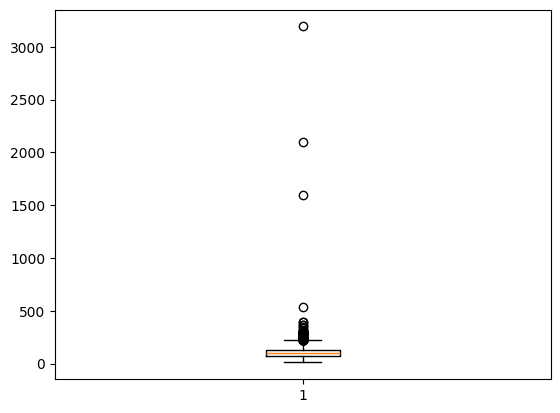

In [43]:
print(plt.boxplot(statement_len))

In [45]:
train.to_csv("/content/drive/MyDrive/NLP - Project/cleaned.csv", index=False)

In [46]:
import os

print(os.listdir("/content/drive/MyDrive/NLP - Project"))

['cleaned.csv']
